In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')  # graficos avanzados

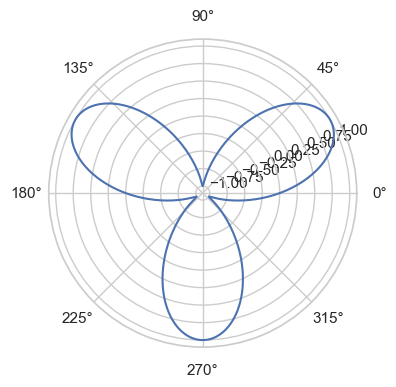

In [86]:
# definicion de las funciones
theta = np.linspace(0, 2 * np.pi, 600) # 600 valores vamos a tomar
r = np.sin(3 * theta)

 # graficar funcion como coordenadas polares
plt.figure(figsize=(4,4))
ax = plt.subplot(111, polar=True)
ax.plot(theta, r, label='En coordenadas polares')
plt.grid(True)
plt.show()

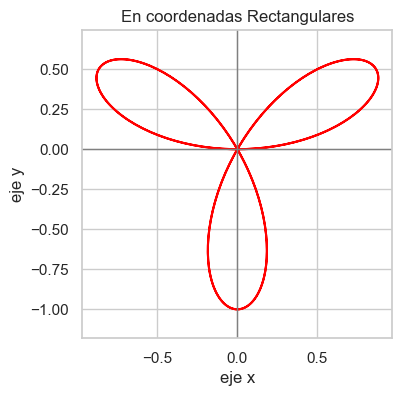

In [87]:
# graficar con coordenada rectangular
x = r * np.cos(theta) 
y = r * np.sin(theta)

plt.figure(figsize=(4,4))
plt.plot(x,y, color='red')
plt.axhline(0,color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.title('En coordenadas Rectangulares')
plt.xlabel('eje x')
plt.ylabel('eje y')
plt.axis('equal')
plt.grid(True)
plt.show()

In [88]:
# guardar los valores como diccionario
paresOrdenados = {
    'theta': theta,
    'r': r
}

df_graph = pd.DataFrame(paresOrdenados)  # guardamos el diccionario como dataFrame

df_graph.to_csv('datosEjercicio2.csv', index=False) # lo guardamos como csv
df_csv = pd.read_csv('datosEjercicio2.csv')  # lo leemos y guardamos en otra variable



In [89]:
# convertir los datos a valores tipo de python
    # df_csv['theta'] = pd.to_numeric(df_csv['theta'], errors='coerce')
    # df_csv['r'] = pd.to_numeric(df_csv['theta'], errors='coerce')
for col in ['theta', 'r']: 
    df_csv[col] = pd.to_numeric(df_csv[col], errors='coerce')

# mostrar primeros 10 datos iniciales y finales e informacion basica del df
print("primeras 5 filas: ")
display(df_graph.head(5))
print("Ultimas 5 filas ")
display(df_graph.tail(5))
df_graph.info()


primeras 5 filas: 


,theta,r
0,0.000000,0.000000
1,0.010489,0.031463
2,0.020979,0.062895
3,0.031468,0.094265
4,0.041958,0.125541


Ultimas 5 filas 


,theta,r
595,6.241227,-1.255414e-01
596,6.251717,-9.426496e-02
597,6.262206,-6.289521e-02
598,6.272696,-3.146318e-02
599,6.283185,-7.347881e-16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   theta   600 non-null    float64
 1   r       600 non-null    float64
dtypes: float64(2)
memory usage: 9.5 KB


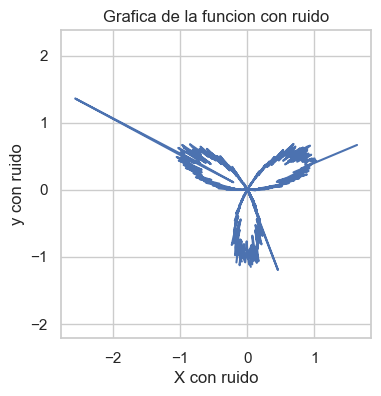

In [90]:
# añadir ruido a la señal
df_csv['r_ruido'] = df_csv['r'] + np.random.normal(0, 0.1, size=(len(df_csv)))

# añadir valores nulos
indices_nulos = np.random.choice(df_csv.index, 15, replace=False) # 15 nan 
df_csv.loc[indices_nulos, 'r_ruido'] = np.nan

# añadir valores atipicos
indices_outliers = np.random.choice(df_csv.index, 5, replace=False) # 5 outliers
df_csv.loc[indices_outliers, 'r_ruido'] += np.random.normal(1, 0.3, size=5)

# guardar columna en csv
df_csv.to_csv('datosEjercicio2.csv', index=False)

# Graficar la senal con ruido
x_ruido = df_csv['r_ruido'] * np.cos(df_csv['theta'])
y_ruido = df_csv['r_ruido'] * np.sin(df_csv['theta'])

plt.figure(figsize=(4,4))
plt.plot(x_ruido, y_ruido)
plt.xlabel('X con ruido')
plt.ylabel('y con ruido')
plt.title('Grafica de la funcion con ruido')
plt.grid(True)
plt.axis('equal')
plt.show()


Estadisticas de datos: 


,theta,r,r_ruido
count,600.000000,6.000000e+02,585.000000
mean,3.141593,-2.368476e-17,-0.004395
std,1.818341,7.071068e-01,0.722524
min,0.000000,-9.999966e-01,-1.204594
25%,1.570796,-7.052482e-01,-0.697876
50%,3.141593,-3.673940e-16,-0.011233
75%,4.712389,7.052482e-01,0.672000
max,6.283185,9.999966e-01,2.904748


Numero de valores nulos:  15


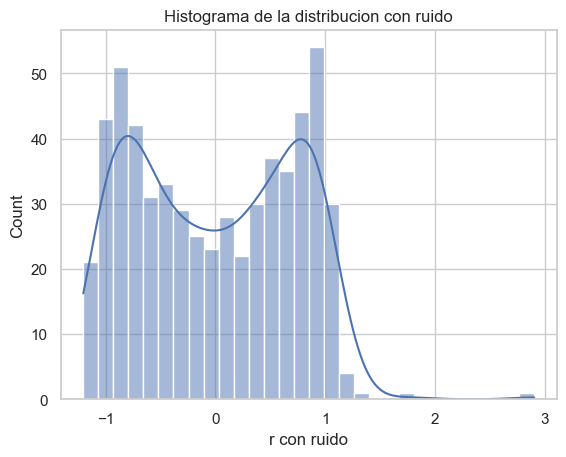

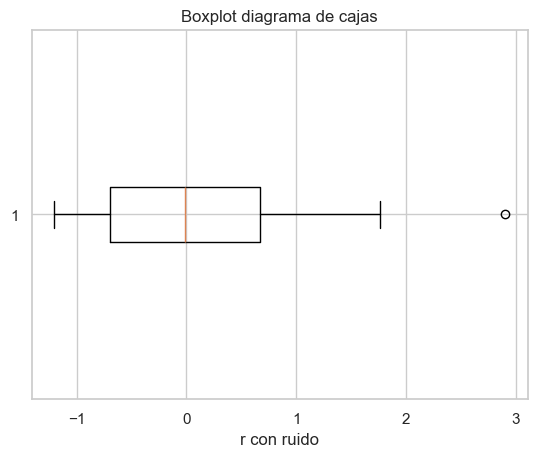

In [91]:
# ESTADISTICA DE DATOS 
print("Estadisticas de datos: ")
display(df_csv.describe())
print("Numero de valores nulos: ", df_csv['r_ruido'].isna().sum())

    # histograma
sns.histplot(df_csv['r_ruido'].dropna(), bins=30, kde=True)
plt.title('Histograma de la distribucion con ruido')
plt.xlabel('r con ruido')
plt.show()

    # diagrama de cajas
plt.boxplot(df_csv['r_ruido'].dropna(), vert=False)
plt.title('Boxplot diagrama de cajas')
plt.xlabel('r con ruido')
plt.show()

In [92]:
# LIMPIEZA DE DATOS
    # HALLAR OUTLIERS
q1 = df_csv['r_ruido'].quantile(0.25)
q3 = df_csv['r_ruido'].quantile(0.75)
riq = q3 - q1

lim_inf = q1 - 1.5*riq
lim_sup = q3 + 1.5*riq

# manejo de outliers con .loc y convertirlos en nan
df_csv.loc[(df_csv['r_ruido'] > lim_sup) | (df_csv['r_ruido']< lim_inf), 'r_ruido'] = np.nan

# interpolar valores nan
df_csv['r_limpia'] = df_csv['r_ruido'].interpolate(method='linear')

    # limpieza con media movil
df_csv['r_limpia'] = df_csv['r_limpia'].rolling(window=7, center=True).mean()
df_csv['r_limpia'] = df_csv['r_limpia'].fillna(method='bfill').fillna(method='ffill')

df_csv.to_csv('datosEjercicio2.csv', index=False)

C:\Users\juann\AppData\Local\Temp\ipykernel_18244\1531732578.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_csv['r_limpia'] = df_csv['r_limpia'].fillna(method='bfill').fillna(method='ffill')


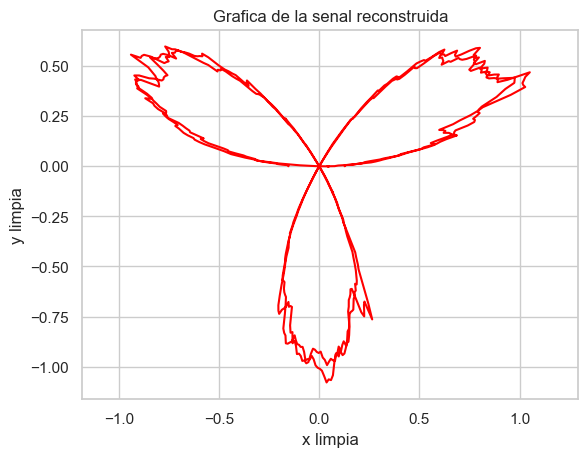

In [93]:
# GRAFICAR LA SENAL RECONSTRUIDA
x_limpia = df_csv['r_limpia']* np.cos(df_csv['theta'])
y_limpia = df_csv['r_limpia']* np.sin(df_csv['theta'])

plt.plot(x_limpia, y_limpia, color='red')
plt.title('Grafica de la senal reconstruida')
plt.xlabel('x limpia')
plt.ylabel('y limpia')
plt.axis('equal')
plt.grid(True)
plt.show()